# Text Module

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv("AI_Human.csv", engine='python', on_bad_lines='skip')

df['generated'] = df['generated'].astype(int)
df = df[df['text'].str.len() > 50]

print(df.head())
print(df['generated'].value_counts())

                                                text  generated
0  Cars. Cars have been around since they became ...          0
1  Transportation is a large necessity in most co...          0
2  "America's love affair with it's vehicles seem...          0
3  How often do you ride in a car? Do you drive a...          0
4  Cars are a wonderful thing. They are perhaps o...          0
generated
0    1375
1     535
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['generated'],
    test_size=0.2,
    stratify=df['generated'],
    random_state=42
)

Stylometric Features exploration

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
def extract_features(text):
    words = text.split()
    sentences = text.split('.')

    return [
        len(text),
        len(words),
        np.mean([len(w) for w in words]) if words else 0,
        len(sentences),
        text.count(','),
        text.count('!'),
        text.count('?'),
        sum(1 for w in words if w.istitle())
    ]

X_train_style = np.array([extract_features(t) for t in X_train])
X_test_style = np.array([extract_features(t) for t in X_test])

# Showing stylometric dataframe
style_df = pd.DataFrame(X_train_style, columns=[
    "char_count", "word_count", "avg_word_len",
    "sentence_count", "commas", "exclamations",
    "questions", "capital_words"
])
print(style_df.head())

   char_count  word_count  avg_word_len  sentence_count  commas  exclamations  \
0      2047.0       409.0      4.000000            28.0    10.0           0.0   
1      3464.0       601.0      4.758735            48.0    12.0           0.0   
2      3520.0       577.0      5.095321            34.0    22.0           0.0   
3      2398.0       407.0      4.884521            23.0    17.0           0.0   
4      3322.0       483.0      5.859213            21.0    40.0           0.0   

   questions  capital_words  
0        0.0           30.0  
1        0.0           56.0  
2        3.0           70.0  
3        0.0           55.0  
4        0.0           61.0  


# Three base models for ensemble

In [ ]:
# Model 1
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

# Model 2
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

# Model 3 (Stylometry)
model_style = RandomForestClassifier(n_estimators=100)
model_style.fit(X_train_style, y_train)

RandomForestClassifier()

In [ ]:
lr_prob = model_lr.predict_proba(X_test_tfidf)[:,1]
nb_prob = model_nb.predict_proba(X_test_tfidf)[:,1]
style_prob = model_style.predict_proba(X_test_style)[:,1]

In [ ]:
meta_X = np.vstack((lr_prob, nb_prob, style_prob)).T

# normalize
scaler = StandardScaler()
meta_X = scaler.fit_transform(meta_X)

# NEURAL NETWORK META MODEL

In [ ]:
meta_model = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

meta_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

meta_model.fit(meta_X, y_test, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2853 - loss: 0.6501
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9607 - loss: 0.5969 
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9974 - loss: 0.5466 
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9974 - loss: 0.4970 
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9974 - loss: 0.4453
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9974 - loss: 0.3930  
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9974 - loss: 0.3415 
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9974 - loss: 0.2925 
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.2468 
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.2108 


In [ ]:
meta_pred_prob = meta_model.predict(meta_X).flatten()
meta_pred = (meta_pred_prob > 0.5).astype(int)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


# Evaluation


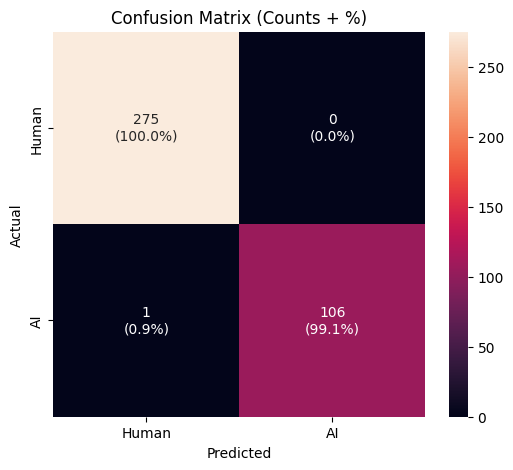

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, meta_pred)

# normalize
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]*100:.1f}%)" for j in range(2)]
    for i in range(2)
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='rocket',
    xticklabels=["Human", "AI"],
    yticklabels=["Human", "AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts + %)")
plt.show()

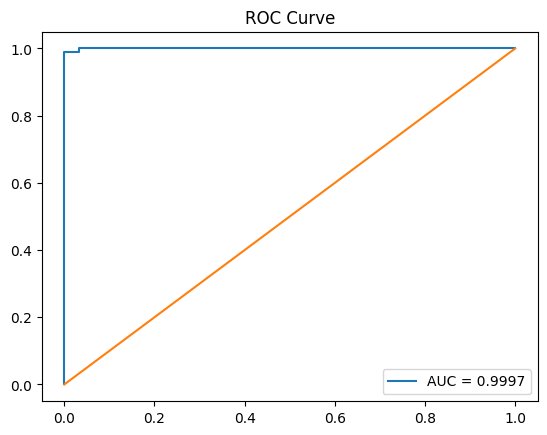

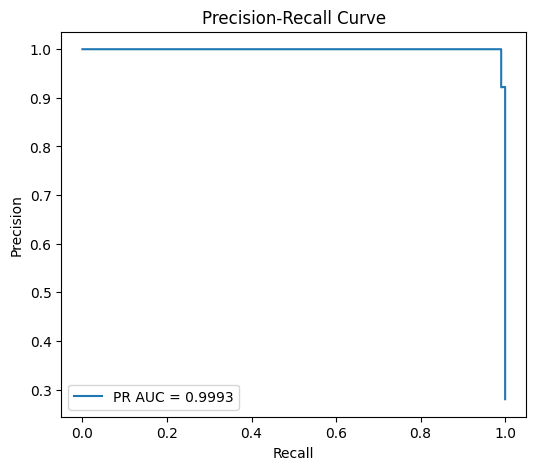

In [ ]:

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, meta_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.legend()
plt.show()


precision, recall, _ = precision_recall_curve(y_test, meta_pred_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:

models = {
    "Logistic": model_lr.predict(X_test_tfidf),
    "Naive Bayes": model_nb.predict(X_test_tfidf),
    "Stylometry": model_style.predict(X_test_style),
    "Neural Ensemble": meta_pred
}

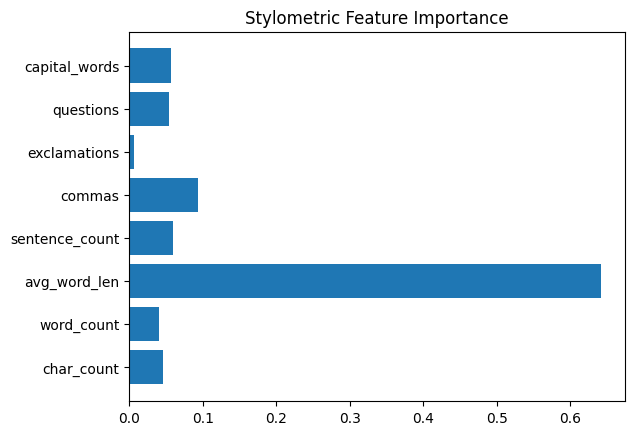

In [ ]:
features = style_df.columns
importances = model_style.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Stylometric Feature Importance")
plt.show()

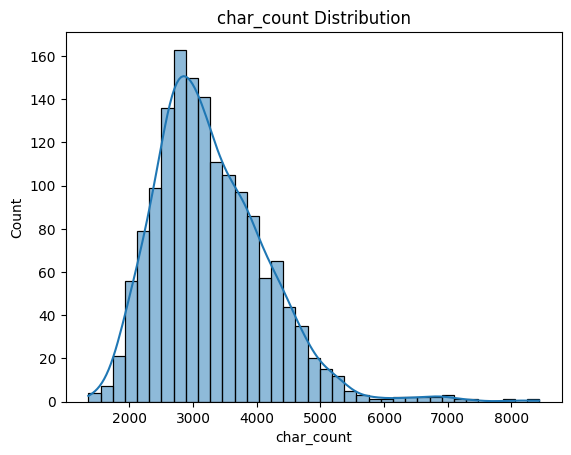

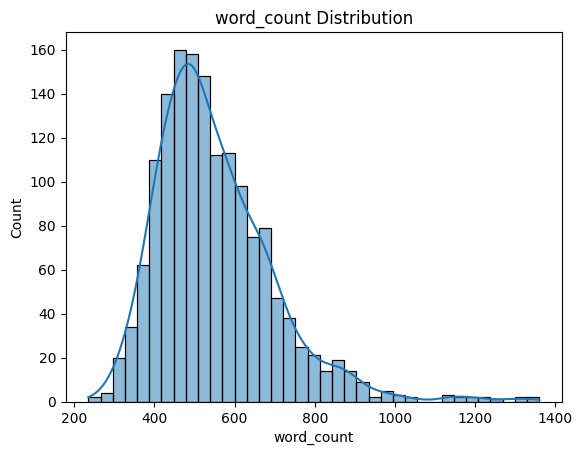

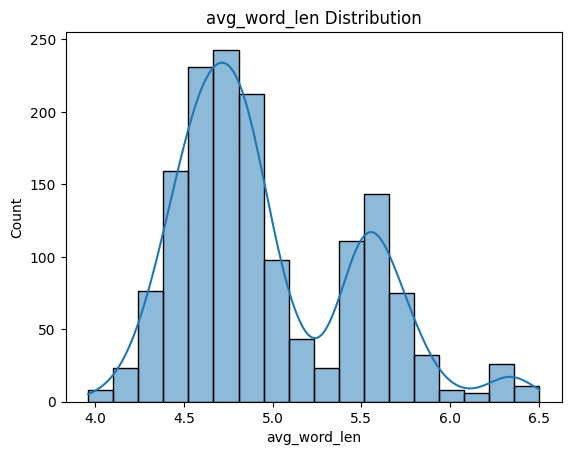

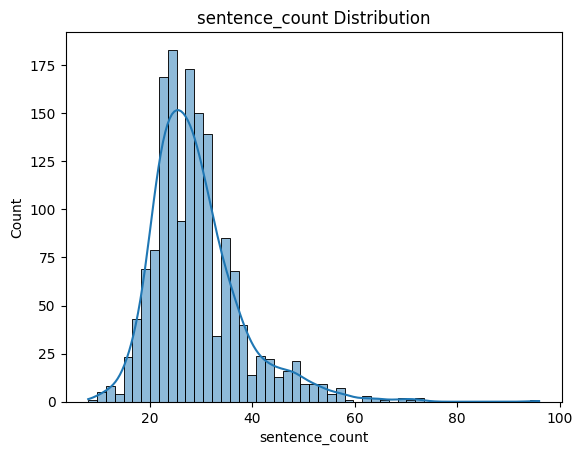

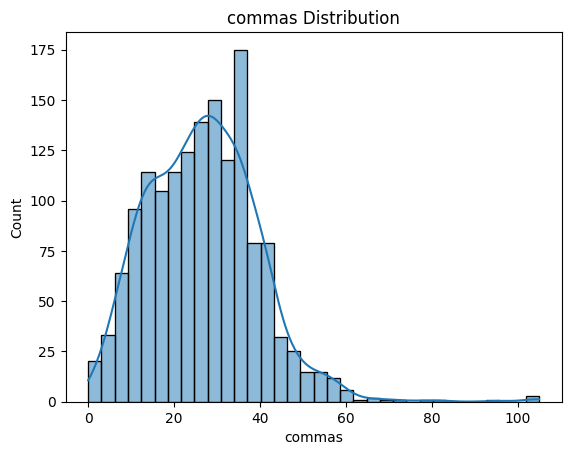

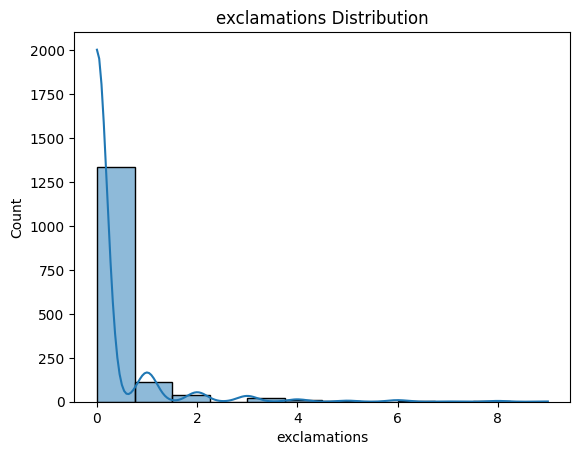

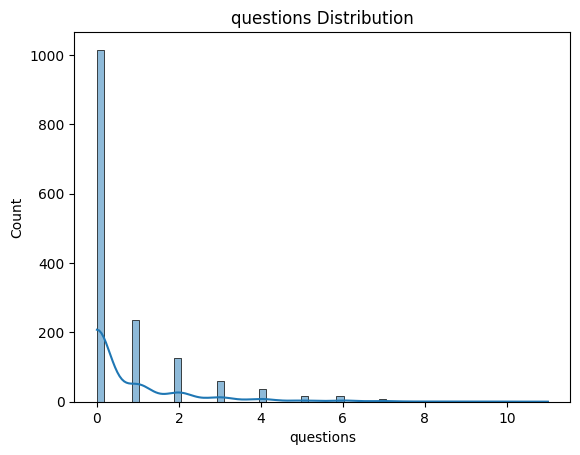

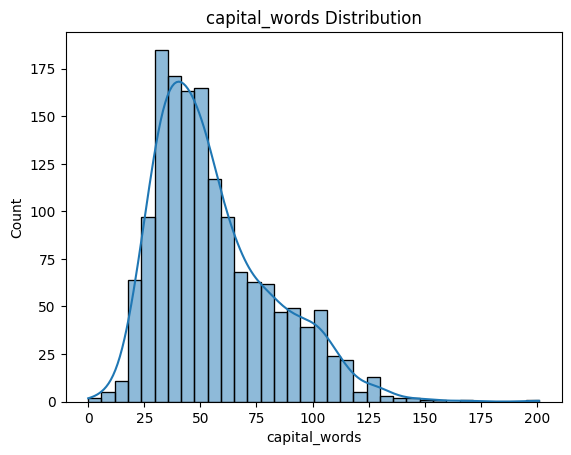

In [ ]:
for col in style_df.columns:
    plt.figure()
    sns.histplot(style_df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [ ]:
wrong = X_test[meta_pred != y_test]
print("\nWRONG PREDICTIONS SAMPLE:\n")
print(wrong.head(10))


WRONG PREDICTIONS SAMPLE:

1262    Limiting car use causes pollution, increases c...
Name: text, dtype: object


# One Shot Performance analysis

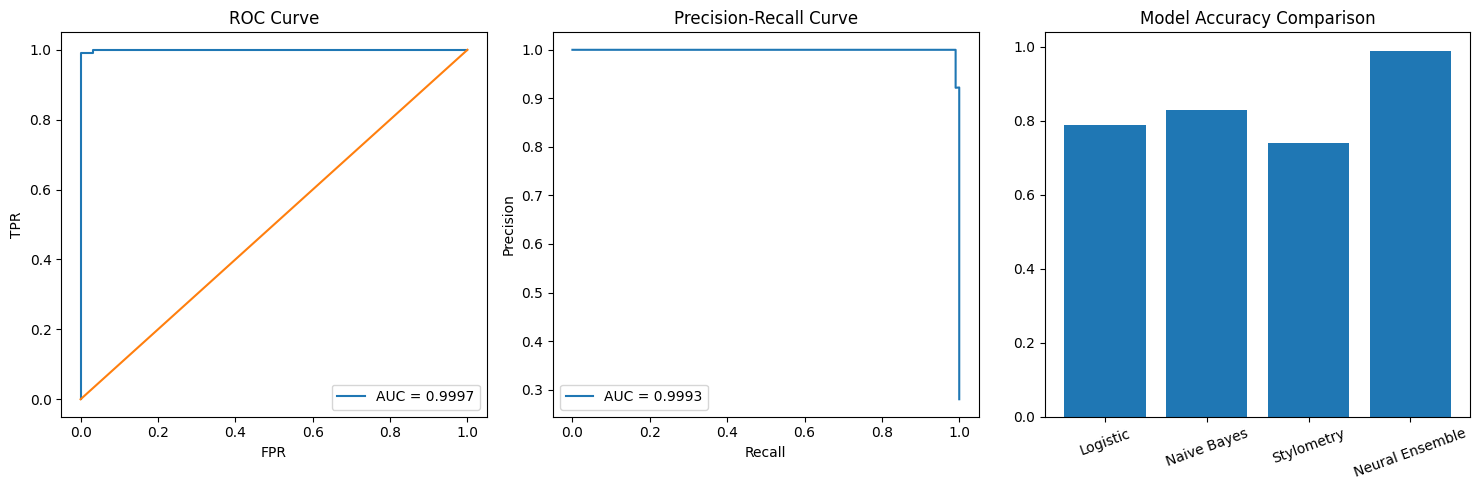

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# ROC
fpr, tpr, _ = roc_curve(y_test, meta_pred_prob)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_test, meta_pred_prob)
pr_auc = auc(recall, precision)

# Model comparison
model_names = ["Logistic", "Naive Bayes", "Stylometry", "Neural Ensemble"]
accuracies = [
    accuracy_score(y_test, model_lr.predict(X_test_tfidf)),
    accuracy_score(y_test, model_nb.predict(X_test_tfidf)),
    accuracy_score(y_test, model_style.predict(X_test_style)),
    accuracy_score(y_test, meta_pred)
]

# PLOT
plt.figure(figsize=(15,5))

# ROC
plt.subplot(1,3,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

# PR
plt.subplot(1,3,2)
plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# Accuracy comparison
plt.subplot(1,3,3)
plt.bar(model_names, accuracy)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()